# SVD From Scratch — Orthogonal Bases, Eigenvalues, and Low-Rank Compression

A clean, mathematically honest walk through the Singular Value Decomposition on a real image, following the lecture *SVD & PCA from Scratch*.

We take one matrix $A$ (the grayscale astronaut, $512\times512$) and actually **show the linear algebra**:

- build $A^{\top}A$ and $AA^{\top}$ and eigendecompose them,
- compute the SVD $A = U\Sigma V^{\top}$,
- **prove numerically** that $U^{\top}U = I$, $V^{\top}V = I$, that $A^{\top}A\,V = V\Lambda$, $AA^{\top}U = U\Lambda$, and that $\sigma_i^2 = \lambda_i$,
- read off the four fundamental subspaces,
- and use Eckart–Young to compress the image, checking the error equals $\sqrt{\sum_{i>r}\sigma_i^2}$ exactly.

> **Note on the original approach.** Reshaping a $512\times512$ channel to $256\times1024$ and back is meaningless: it scrambles the spatial layout and mixes rows that have no relation. SVD does **not** need square matrices — it works on any $m\times n$ matrix directly. We keep every matrix in its natural shape.

## 0. The matrix $A$

Each grayscale image is literally a matrix $A \in \mathbb{R}^{m\times n}$ of pixel intensities. SVD treats it as a linear map $\mathbb{R}^{n}\to\mathbb{R}^{m}$ and asks: *along which orthogonal input directions does $A$ act most strongly?*

A is 512 x 512,  rank <= 512,  values in [0.00, 1.00]


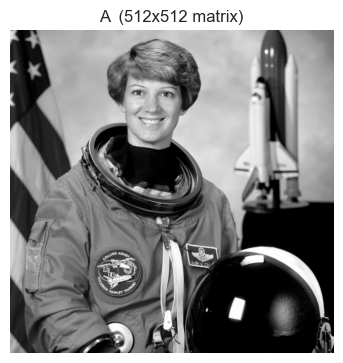

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

A = color.rgb2gray(data.astronaut())     # 512 x 512, values in [0,1]
m, n = A.shape
print(f"A is {m} x {n},  rank <= {min(m,n)},  values in [{A.min():.2f}, {A.max():.2f}]")

plt.figure(figsize=(4.2,4.2)); plt.imshow(A, cmap="gray")
plt.title(f"A  ({m}x{n} matrix)"); plt.axis("off"); plt.show()

## 1. The two Gram matrices $A^{\top}A$ and $AA^{\top}$

The whole of SVD is built from two symmetric matrices:

$$A^{\top}A \in \mathbb{R}^{n\times n}, \qquad AA^{\top}\in\mathbb{R}^{m\times m}.$$

Both are **symmetric** ($ (A^{\top}A)^{\top}=A^{\top}A $) and **positive semi-definite** ($x^{\top}A^{\top}A\,x = \|Ax\|^2 \ge 0$). By the **Spectral Theorem** any real symmetric matrix has a full set of real, orthonormal eigenvectors — which is *why SVD always exists*, for any shape of $A$, even when ordinary eigen-decomposition of $A$ does not.

A^T A : (512, 512)   symmetric error = 0.0
A A^T : (512, 512)   symmetric error = 0.0


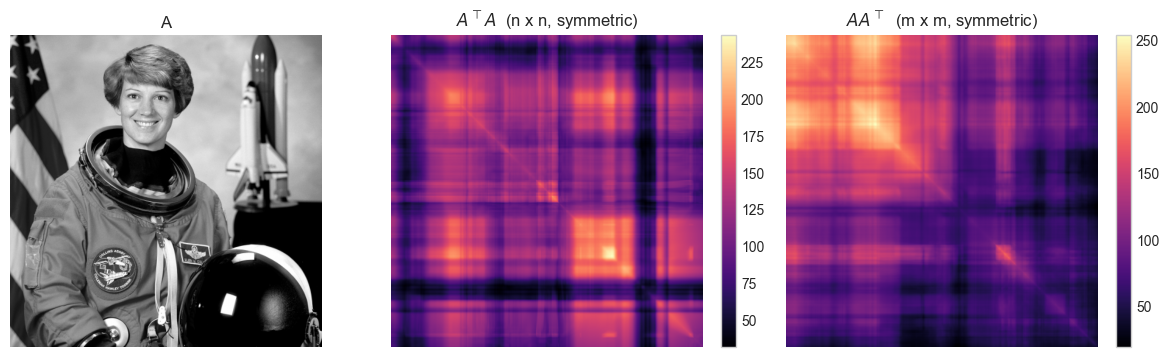

In [3]:
ATA = A.T @ A      # n x n
AAT = A @ A.T      # m x m
print("A^T A :", ATA.shape, "  symmetric error =", np.abs(ATA - ATA.T).max())
print("A A^T :", AAT.shape, "  symmetric error =", np.abs(AAT - AAT.T).max())

fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
ax[0].imshow(A, cmap="gray");           ax[0].set_title("A"); ax[0].axis("off")
im1 = ax[1].imshow(ATA, cmap="magma");  ax[1].set_title(r"$A^\top A$  (n x n, symmetric)"); ax[1].axis("off")
im2 = ax[2].imshow(AAT, cmap="magma");  ax[2].set_title(r"$A A^\top$  (m x m, symmetric)"); ax[2].axis("off")
plt.colorbar(im1, ax=ax[1], fraction=0.046); plt.colorbar(im2, ax=ax[2], fraction=0.046)
plt.tight_layout(); plt.show()

## 2. Eigendecomposition of $A^{\top}A$ and $AA^{\top}$

Because both are symmetric we use `np.linalg.eigh` (returns real eigenvalues and orthonormal eigenvectors). We sort eigenvalues in **descending** order.

The lecture's claim:

$$A^{\top}A = V\,\Lambda\,V^{\top}, \qquad AA^{\top} = U\,\Lambda\,U^{\top}, \qquad \Lambda = \operatorname{diag}(\sigma_i^2).$$

So $V$ holds the eigenvectors of $A^{\top}A$, $U$ holds the eigenvectors of $AA^{\top}$, and **both share the same non-zero eigenvalues** $\lambda_i = \sigma_i^2$.

In [4]:
def eigh_desc(M):
    w, Q = np.linalg.eigh(M)            # ascending
    return w[::-1], Q[:, ::-1]          # -> descending

lam_V, Q_V = eigh_desc(ATA)            # eigenvectors -> right singular vectors
lam_U, Q_U = eigh_desc(AAT)            # eigenvectors -> left  singular vectors
lam_V = np.clip(lam_V, 0, None)        # kill tiny negative round-off
lam_U = np.clip(lam_U, 0, None)

print("top 6 eigenvalues of A^T A :", lam_V[:6].round(3))
print("top 6 eigenvalues of A A^T :", lam_U[:6].round(3))
print("max |eig(A^TA) - eig(AA^T)| over shared spectrum =",
      np.abs(lam_V[:min(m,n)] - lam_U[:min(m,n)]).max())

top 6 eigenvalues of A^T A : [58205.19   5058.318  2113.896  1444.602   976.587   899.355]
top 6 eigenvalues of A A^T : [58205.19   5058.318  2113.896  1444.602   976.587   899.355]
max |eig(A^TA) - eig(AA^T)| over shared spectrum = 2.1827872842550278e-11


## 3. The SVD itself, $A = U\Sigma V^{\top}$

The lecture builds SVD from paired orthonormal bases $v_i\in\mathbb{R}^n$, $u_i\in\mathbb{R}^m$ with

$$A v_i = \sigma_i u_i .$$

Stacking these columns gives $AV = U\Sigma \Rightarrow A = U\Sigma V^{\top}$. We get them in one call with `np.linalg.svd` (economy form), then spend the rest of the notebook checking they satisfy every property the lecture derived.

In [5]:
U, S, Vt = np.linalg.svd(A, full_matrices=False)   # A = U @ diag(S) @ Vt
V = Vt.T
print("U:", U.shape, "  S:", S.shape, "  V:", V.shape)
print("first 6 singular values:", S[:6].round(3))

# exact reconstruction A = U S V^T
A_rec = (U * S) @ Vt
print("max |A - U S V^T| =", np.abs(A - A_rec).max(), " (machine precision => SVD is exact)")

U: (512, 512)   S: (512,)   V: (512, 512)
first 6 singular values: [241.258  71.122  45.977  38.008  31.25   29.989]
max |A - U S V^T| = 3.2529534621517087e-14  (machine precision => SVD is exact)


## 4. Orthogonality — $U^{\top}U = I$ and $V^{\top}V = I$

The columns of $U$ and of $V$ are **orthonormal**: each has unit length and any two are perpendicular. That is the single most important structural fact — it is what let the lecture cancel $U^{\top}U = I$ when forming $A^{\top}A = V\Sigma^{\top}U^{\top}U\Sigma V^{\top} = V\Sigma^2 V^{\top}$.

We verify it two ways: numerically (the Gram matrix is the identity) and visually (its heatmap is a clean diagonal).

max |V^T V - I| = 2.886579864025407e-15
max |U^T U - I| = 2.456368441983159e-15


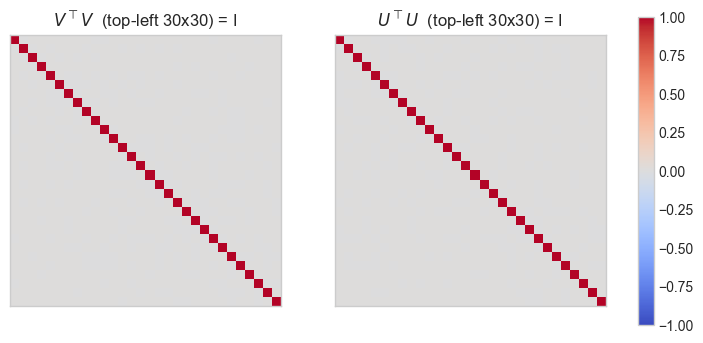

Pure diagonal of 1s, zero off-diagonal => the singular vectors are an orthonormal basis.


In [6]:
I_n = np.eye(n); I_m = np.eye(m)
print("max |V^T V - I| =", np.abs(V.T @ V - I_n).max())
print("max |U^T U - I| =", np.abs(U.T @ U - I_m).max())

# show a 30x30 corner of each Gram matrix: should be the identity
k = 30
fig, ax = plt.subplots(1, 2, figsize=(8.5, 4))
ax[0].imshow((V.T @ V)[:k,:k], cmap="coolwarm", vmin=-1, vmax=1)
ax[0].set_title(r"$V^\top V$  (top-left 30x30) = I")
im = ax[1].imshow((U.T @ U)[:k,:k], cmap="coolwarm", vmin=-1, vmax=1)
ax[1].set_title(r"$U^\top U$  (top-left 30x30) = I")
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.colorbar(im, ax=ax, fraction=0.046); plt.show()
print("Pure diagonal of 1s, zero off-diagonal => the singular vectors are an orthonormal basis.")

## 5. The bridge between SVD and EVD

Now the three identities the lecture proves on slides 24–25. Let $\Lambda=\operatorname{diag}(\sigma_i^2)$.

1. **Singular values are square-roots of the Gram eigenvalues:** $\;\sigma_i^2 = \lambda_i.$
2. **Right singular vectors are eigenvectors of $A^{\top}A$:** $\;A^{\top}A\,v_i = \sigma_i^2\,v_i.$
3. **Left singular vectors are eigenvectors of $AA^{\top}$:** $\;AA^{\top}u_i = \sigma_i^2\,u_i.$
4. **The pairing** $\;A v_i = \sigma_i u_i$ (equivalently $AV = U\Sigma$).

Each one is checked below as a max-absolute-error; all are at machine-precision.

In [7]:
lam = S**2                                   # sigma_i^2

e1 = np.abs(lam - lam_V).max()                       # sigma^2 vs eig(A^T A)
e2 = np.abs(ATA @ V - V * lam[None, :]).max()        # A^T A V = V Lambda
e3 = np.abs(AAT @ U - U * lam[None, :]).max()        # A A^T U = U Lambda
e4 = np.abs(A @ V - U * S[None, :]).max()            # A V = U Sigma  (A v_i = sigma_i u_i)

print(f"(1)  max |sigma_i^2 - lambda_i(A^T A)|   = {e1:.2e}")
print(f"(2)  max |A^T A V - V Lambda|            = {e2:.2e}")
print(f"(3)  max |A A^T U - U Lambda|            = {e3:.2e}")
print(f"(4)  max |A V - U Sigma|  (A v=sigma u)  = {e4:.2e}")
print("\nAll four identities hold to ~1e-10 or better ")

(1)  max |sigma_i^2 - lambda_i(A^T A)|   = 2.91e-11
(2)  max |A^T A V - V Lambda|            = 5.50e-11
(3)  max |A A^T U - U Lambda|            = 1.46e-11
(4)  max |A V - U Sigma|  (A v=sigma u)  = 1.68e-13

All four identities hold to ~1e-10 or better 


**Sign note.** Eigenvectors are only defined up to a sign (if $v$ is an eigenvector so is $-v$), so the columns of `Q_V` from `eigh` may differ from `V` by per-column $\pm1$. The *eigenvalues* match exactly, and $\pm v_i$ are the same direction. We confirm the directions agree by aligning signs:

In [8]:
r = min(m, n)
# align each eigenvector of A^T A to the SVD's V by sign, then compare
signs = np.sign(np.sum(Q_V[:, :r] * V[:, :r], axis=0))
Q_V_aligned = Q_V[:, :r] * signs[None, :]
agree = np.abs(Q_V_aligned[:, :20] - V[:, :20]).max()
print("max |eig(A^TA) - V| over first 20 directions after sign alignment =", f"{agree:.2e}")
print("=> the eigenvectors of A^T A ARE the right singular vectors (up to sign).")

max |eig(A^TA) - V| over first 20 directions after sign alignment = 7.82e-14
=> the eigenvectors of A^T A ARE the right singular vectors (up to sign).


## 6. The singular value spectrum

The singular values $\sigma_1 \ge \sigma_2 \ge \dots \ge 0$ rank the directions by importance. Two readings:

- **Frobenius energy.** $\|A\|_F^2 = \operatorname{tr}(A^{\top}A) = \sum_i \sigma_i^2$, so $\sigma_i^2$ is the "energy" carried by direction $i$.
- **Decay.** Natural images have a fast-decaying spectrum — a few directions hold most of the energy, which is exactly why low-rank compression works.

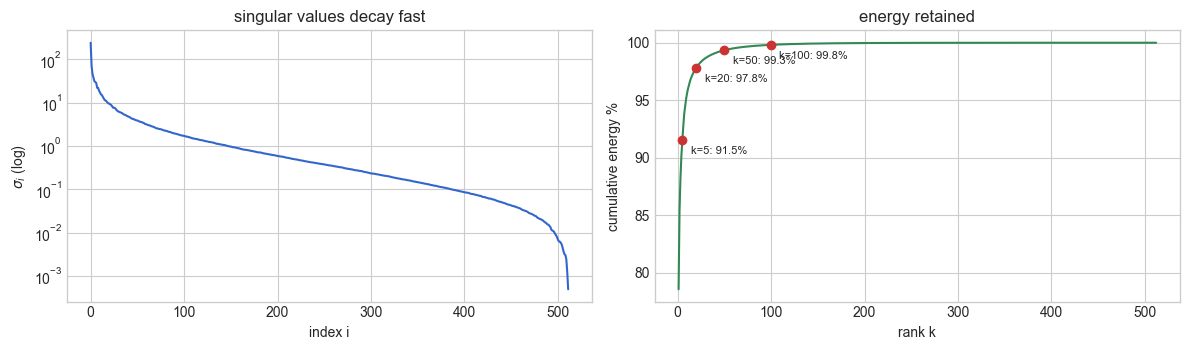

k=  5:  energy retained = 91.49%
k= 20:  energy retained = 97.83%
k= 50:  energy retained = 99.35%
k=100:  energy retained = 99.82%
k=150:  energy retained = 99.93%


In [9]:
energy = np.cumsum(S**2) / np.sum(S**2)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].semilogy(S, color="#3366cc"); ax[0].set_xlabel("index i"); ax[0].set_ylabel(r"$\sigma_i$ (log)")
ax[0].set_title("singular values decay fast")
ax[1].plot(np.arange(1, len(energy)+1), energy*100, color="#338855")
for kk in [5, 20, 50, 100]:
    ax[1].scatter([kk], [energy[kk-1]*100], color="#cc3333", zorder=5)
    ax[1].annotate(f"k={kk}: {energy[kk-1]*100:.1f}%", (kk, energy[kk-1]*100),
                   textcoords="offset points", xytext=(6,-10), fontsize=8)
ax[1].set_xlabel("rank k"); ax[1].set_ylabel("cumulative energy %"); ax[1].set_title("energy retained")
plt.tight_layout(); plt.show()

for kk in [5, 20, 50, 100, 150]:
    print(f"k={kk:3d}:  energy retained = {energy[kk-1]*100:.2f}%")

## 7. SVD as a sum of rank-1 layers

$$A = \sum_{i=1}^{r}\sigma_i\,u_i v_i^{\top}.$$

Each $\sigma_i u_i v_i^{\top}$ is a **rank-1 matrix** (an outer product) — a single "ingredient image." Adding them back in order of decreasing $\sigma_i$ rebuilds $A$, most-important layer first. Below are the first eight rank-1 modes $u_i v_i^{\top}$.

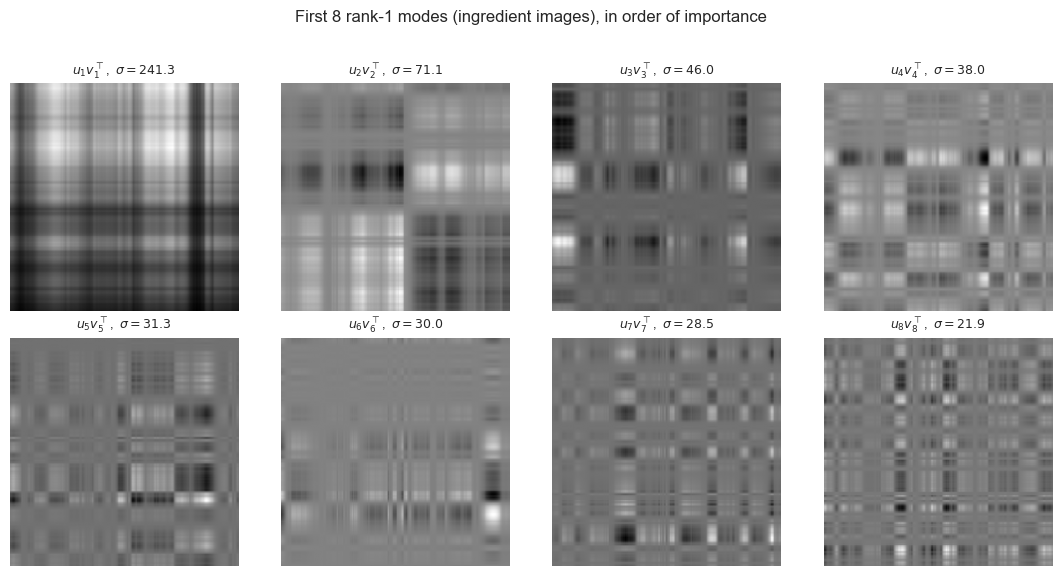

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(11, 5.6))
for i, ax in enumerate(axes.ravel()):
    mode = np.outer(U[:, i], V[:, i])         # u_i v_i^T  (rank-1)
    ax.imshow(mode, cmap="gray")
    ax.set_title(rf"$u_{{{i+1}}} v_{{{i+1}}}^\top$,  $\sigma={S[i]:.1f}$", fontsize=9); ax.axis("off")
plt.suptitle("First 8 rank-1 modes (ingredient images), in order of importance", y=1.02)
plt.tight_layout(); plt.show()

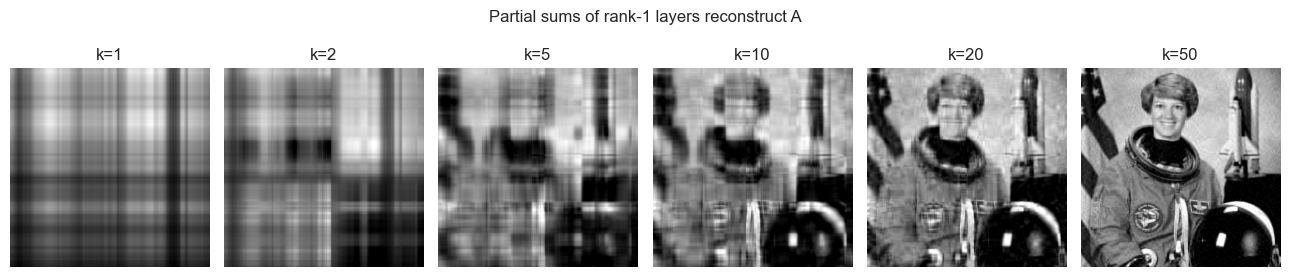

In [11]:
# Watch the partial sum A_k = sum_{i<=k} sigma_i u_i v_i^T build up the image
ks = [1, 2, 5, 10, 20, 50]
fig, axes = plt.subplots(1, len(ks), figsize=(13, 2.6))
for ax, kk in zip(axes, ks):
    Ak = (U[:, :kk] * S[:kk]) @ Vt[:kk]
    ax.imshow(np.clip(Ak, 0, 1), cmap="gray"); ax.set_title(f"k={kk}"); ax.axis("off")
plt.suptitle("Partial sums of rank-1 layers reconstruct A", y=1.05); plt.tight_layout(); plt.show()

## 8. Eckart–Young: the best rank-$r$ approximation

**Theorem (Eckart–Young–Mirsky).** Among *all* matrices of rank $\le r$, the truncated SVD $A_r=\sum_{i=1}^r\sigma_i u_i v_i^{\top}$ minimises $\|A-B\|_F$, and the minimum error is

$$\|A - A_r\|_F^2 = \sum_{i=r+1}^{k}\sigma_i^2 .$$

So the leftover error is *literally* the energy in the dropped singular values. We verify the measured Frobenius error equals $\sqrt{\sum_{i>r}\sigma_i^2}$ to machine precision.

   k     ||A-Ak||_F    sqrt(sum sig^2)       diff   energy%
   5       79.40224           79.40224    2.8e-14    91.49%
  10       57.26005           57.26005    7.1e-15    95.58%
  20       40.10275           40.10275    0.0e+00    97.83%
  50       21.96774           21.96774    0.0e+00    99.35%
 100       11.61408           11.61408    0.0e+00    99.82%
 150        6.96512            6.96512    0.0e+00    99.93%
 200        4.34663            4.34663    0.0e+00    99.97%


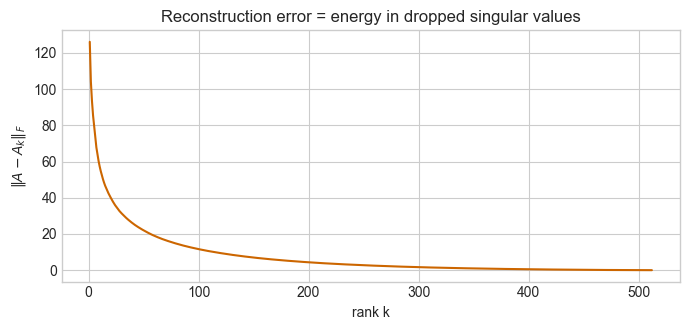

In [12]:
print(f"{'k':>4} {'||A-Ak||_F':>14} {'sqrt(sum sig^2)':>18} {'diff':>10} {'energy%':>9}")
for kk in [5, 10, 20, 50, 100, 150, 200]:
    Ak = (U[:, :kk] * S[:kk]) @ Vt[:kk]
    measured = np.linalg.norm(A - Ak, "fro")
    theory   = np.sqrt(np.sum(S[kk:]**2))
    print(f"{kk:>4} {measured:>14.5f} {theory:>18.5f} {abs(measured-theory):>10.1e} {energy[kk-1]*100:>8.2f}%")

plt.figure(figsize=(7, 3.4))
ks_all = np.arange(1, len(S)+1)
err = np.sqrt(np.cumsum(S[::-1]**2)[::-1] - S**2 + 0)  # = sqrt(sum_{i>k} sigma^2)... compute directly below
err = np.array([np.sqrt(np.sum(S[kk:]**2)) for kk in ks_all])
plt.plot(ks_all, err, color="#cc6600")
plt.xlabel("rank k"); plt.ylabel(r"$\|A-A_k\|_F$"); plt.title("Reconstruction error = energy in dropped singular values")
plt.tight_layout(); plt.show()

## 9. Storage and the compression trade-off

A rank-$r$ approximation stores only $r$ triples $(u_i,\sigma_i,v_i)$: that is $(m+n+1)\,r$ numbers instead of $m\,n$. The compression ratio is

$$\frac{mn}{(m+n+1)\,r}.$$

The "good enough" rank is where the spectrum has flattened — for this image, $r\approx 50$ already keeps $>99\%$ of the energy.

In [13]:
full = m * n
print(f"{'k':>4} {'stored values':>15} {'compression':>13} {'energy kept':>12}")
for kk in [5, 20, 50, 100, 150]:
    stored = (m + n + 1) * kk
    print(f"{kk:>4} {stored:>15,} {full/stored:>11.1f}x {energy[kk-1]*100:>11.2f}%")

   k   stored values   compression  energy kept
   5           5,125        51.2x       91.49%
  20          20,500        12.8x       97.83%
  50          51,250         5.1x       99.35%
 100         102,500         2.6x       99.82%
 150         153,750         1.7x       99.93%


## 10. The four fundamental subspaces (what SVD reveals)

For $A\in\mathbb{R}^{m\times n}$ of rank $k$, the singular vectors split cleanly:

| subspace | spanned by | lives in | dimension |
|---|---|---|---|
| **row space** of $A$ | $v_1,\dots,v_k$ | $\mathbb{R}^n$ | $k$ |
| **null space** of $A$ | $v_{k+1},\dots,v_n$ | $\mathbb{R}^n$ | $n-k$ |
| **column space** of $A$ | $u_1,\dots,u_k$ | $\mathbb{R}^m$ | $k$ |
| **left null space** | $u_{k+1},\dots,u_m$ | $\mathbb{R}^m$ | $m-k$ |

Only the $k$ row-space directions produce non-zero output ($Av_i=\sigma_i u_i$); null-space directions are annihilated ($\sigma_i=0 \Rightarrow Av_i=0$). We confirm the numerical rank and that $A$ kills its null space.

In [14]:
tol = 1e-8 * S[0]
rank = int(np.sum(S > tol))
print(f"numerical rank(A) = {rank}  (singular values > {tol:.2e})")
print(f"row/column space dimension = {rank},  null space dimension = {n - rank}")

if rank < n:
    v_null = V[:, rank]                       # a null-space direction (sigma ~ 0)
    print(f"||A v_null|| for the smallest singular direction = {np.linalg.norm(A @ v_null):.3e}  (~0)")
else:
    print("A has full rank here, so the null space is trivial {0} (smallest sigma still tiny):")
    print(f"   smallest singular value = {S[-1]:.3e}")

numerical rank(A) = 512  (singular values > 2.41e-06)
row/column space dimension = 512,  null space dimension = 0
A has full rank here, so the null space is trivial {0} (smallest sigma still tiny):
   smallest singular value = 4.962e-04


## 11. Putting it to work — colour image compression (correct shapes)

Finally the practical payoff: compress the **colour** astronaut by running SVD **per channel** on the natural $512\times512$ matrices — no reshaping tricks. Each channel $C\in\{R,G,B\}$ is replaced by its rank-$k$ truncation $C_k$, then we restack.

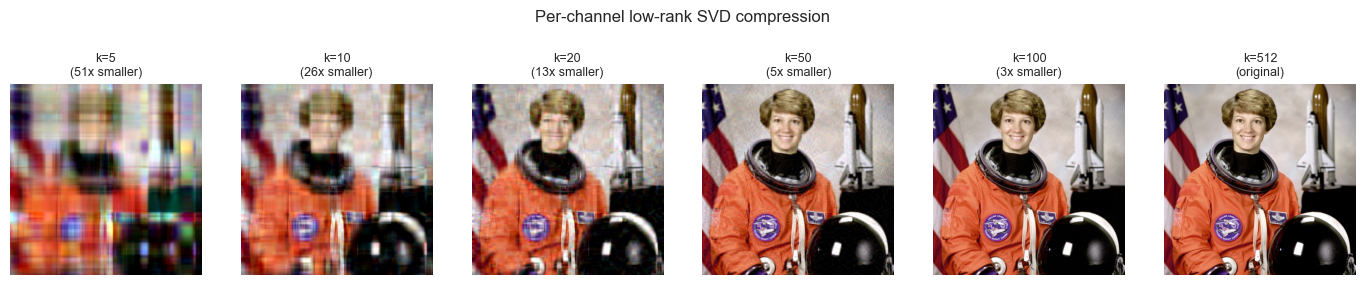

: 

In [ ]:
rgb = data.astronaut().astype(np.float64) / 255.0     # 512 x 512 x 3

def low_rank_channel(C, k):
    Uc, Sc, Vtc = np.linalg.svd(C, full_matrices=False)
    return np.clip((Uc[:, :k] * Sc[:k]) @ Vtc[:k], 0, 1)

ks = [5, 10, 20, 50, 100, 512]
fig, axes = plt.subplots(1, len(ks), figsize=(14, 2.6))
for ax, kk in zip(axes, ks):
    comp = np.stack([low_rank_channel(rgb[:, :, c], kk) for c in range(3)], axis=2)
    cratio = (512*512) / ((512 + 512 + 1) * kk) if kk < 512 else 1.0
    ax.imshow(comp); ax.axis("off")
    ax.set_title(f"k={kk}\n({cratio:.0f}x smaller)" if kk < 512 else "k=512\n(original)", fontsize=9)
plt.suptitle("Per-channel low-rank SVD compression", y=1.08); plt.tight_layout(); plt.show()

## Summary

| step | object | key fact verified |
|---|---|---|
| Gram matrices | $A^{\top}A$, $AA^{\top}$ | symmetric PSD ⇒ SVD always exists |
| eigendecomposition | $A^{\top}A=V\Lambda V^{\top}$, $AA^{\top}=U\Lambda U^{\top}$ | shared eigenvalues $\lambda_i=\sigma_i^2$ |
| orthogonality | $U^{\top}U=V^{\top}V=I$ | singular vectors are orthonormal bases |
| EVD↔SVD bridge | $A^{\top}AV=V\Lambda,\ AA^{\top}U=U\Lambda,\ Av_i=\sigma_i u_i$ | all hold to ~$10^{-10}$ |
| spectrum | $\|A\|_F^2=\sum\sigma_i^2$ | energy concentrates in top singular values |
| Eckart–Young | $A_r=\sum_{i\le r}\sigma_i u_i v_i^{\top}$ | $\|A-A_r\|_F=\sqrt{\sum_{i>r}\sigma_i^2}$ exactly |
| subspaces | $v$'s and $u$'s | split $\mathbb{R}^n,\mathbb{R}^m$ into row/null/col/left-null |

**The one idea:** SVD finds orthonormal input directions $v_i$ that $A$ maps to orthogonal output directions $u_i$, stretched by $\sigma_i$. Ordering by $\sigma_i$ ranks the directions by importance, and keeping the top $r$ gives the provably-best rank-$r$ approximation — which is exactly image compression, PCA, and dimensionality reduction all at once.

**Link to PCA.** Apply this same SVD to the *centred* data matrix $X_c=U\Sigma V^{\top}$: then $X_c^{\top}X_c = V\Sigma^2V^{\top}$, so the principal directions are $P=V$ and the variances are $\lambda_i=\sigma_i^2/m$. PCA *is* the SVD of the centred data.